# 02 - Embedding Pipeline (Movies Final)

Mục tiêu:
1. Load dữ liệu đã qua EDA (`movies_final_for_embedding.csv`)
2. Chạy thử nhiều model embedding
3. Trực quan embedding space (PCA)
4. Test semantic search
5. Build ChromaDB index (prototype)

## I. Import + Config

In [4]:
# !pip install sentence_transformers chromadb
import os
import ast
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import chromadb

## II. Load dữ liệu và kiểm tra nhanh
Đọc file `movies_final.csv` từ thư mục processed. Đảm bảo dữ liệu đã có sẵn cột `rich_text` được tạo từ các bước Data Preparation trước đó.


In [5]:
DATA_PATH = "../backend/data/processed/movies_final.csv"  # Đã đổi tên file
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)


Shape: (35798, 11)
Columns: ['imdb_id', 'title', 'year', 'genres', 'runtime', 'rating', 'votes', 'director', 'cast', 'plots', 'rich_text']


,imdb_id,title,year,genres,runtime,rating,votes,director,cast,plots,rich_text
0,tt0035423,Kate & Leopold,2001.0,"['Comedy', 'Fantasy', 'Romance']",118.0,6.4,94017,James Mangold,"Meg Ryan, Hugh Jackman, Liev Schreiber",When her scientist ex-boyfriend discovers a po...,Title: Kate & Leopold (2001.0)\nGenres: ['Come...
1,tt0038687,Let There Be Light,1980.0,"['Documentary', 'War']",58.0,7.4,2178,NaN,Walter Huston,The final entry in a trilogy of films produced...,Title: Let There Be Light (1980.0)\nGenres: ['...
2,tt0062285,"Oh, Sun",1970.0,['Drama'],98.0,7.4,1088,Med Hondo,"Robert Liensol, Théo Légitimus, Ambroise M'Bia",An educated native of Mauritania tries to find...,"Title: Oh, Sun (1970.0)\nGenres: ['Drama']\nRa..."


In [6]:
required_cols = ["imdb_id", "title", "plots", "rich_text"]
for c in required_cols:
    assert c in df.columns, f"Thiếu cột bắt buộc: {c}"

print("Null rich_text:", df["rich_text"].isna().sum())
print("Duplicate imdb_id:", df["imdb_id"].astype(str).duplicated().sum())


Null rich_text: 0
Duplicate imdb_id: 0


## III. So sánh tốc độ model embedding
Lấy một sample nhỏ để test tốc độ encode của các model sentence-transformers khác nhau. Giúp ta cân nhắc sự đánh đổi giữa tốc độ và độ chính xác trước khi chạy cho toàn bộ tập dữ liệu.


In [7]:
sample_n = min(1000, len(df))
df_sample = df.sample(sample_n, random_state=42).copy()

models_to_test = [
    "all-MiniLM-L6-v2",
    "all-mpnet-base-v2",
]

benchmark = []
for model_name in models_to_test:
    model = SentenceTransformer(model_name)
    start = time.time()
    # Dùng cột rich_text đã có sẵn
    embs = model.encode(df_sample["rich_text"].tolist(), normalize_embeddings=True, show_progress_bar=False)
    elapsed = time.time() - start
    benchmark.append({
        "model": model_name,
        "seconds": round(elapsed, 2),
        "dim": int(embs.shape[1]),
        "rows": len(df_sample),
    })

pd.DataFrame(benchmark)


c:\Users\ADMIN\anaconda3\envs\movie_recommend\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1372.29it/s]
c:\Users\ADMIN\

,model,seconds,dim,rows
0,all-MiniLM-L6-v2,42.54,384,1000
1,all-mpnet-base-v2,226.31,768,1000


## IV. Chọn model chính và tạo embedding cho sample để trực quan
Sau khi xem xét tốc độ ở bước trên, chọn ra model phù hợp nhất. `all-MiniLM-L6-v2` thường là lựa chọn cân bằng tốt cho prototype do tốc độ siêu nhanh và chất lượng khá tốt.


In [8]:
MODEL_NAME = "all-MiniLM-L6-v2"
model = SentenceTransformer(MODEL_NAME)

sample_emb = model.encode(
    df_sample["rich_text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
)

print("Sample embedding shape:", sample_emb.shape)


Batches: 100%|██████████| 32/32 [00:33<00:00,  1.06s/it]

Sample embedding shape: (1000, 384)


## V. PCA 2D để trực quan không gian Embedding
Sử dụng PCA (Principal Component Analysis) để giảm chiều dữ liệu embedding từ 384 chiều xuống 2 chiều. Trực quan hóa giúp ta xem các bộ phim có phân bố dạng cụm (clusters) hợp lý không.


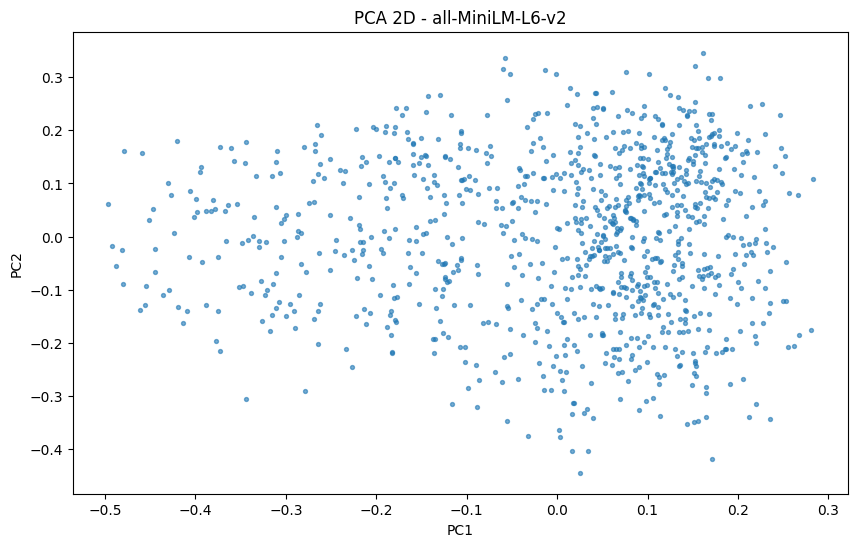

In [9]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(sample_emb)

df_sample["x"] = coords[:, 0]
df_sample["y"] = coords[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(df_sample["x"], df_sample["y"], s=8, alpha=0.6)
plt.title(f"PCA 2D - {MODEL_NAME}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## Nhận xét: 

- Kết quả khá ổn khi không thấy các outlier bị cách quá xa

- Phân bố có 1 vùng dày bên phải và vùng thưa bên trái, cho thấy dữ liệu có vài cụm tự nhiên 

- Nên thử tô màu theo `genre` để xem các cụm này có ý nghĩa không? 